# **Libraries**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, TimeDistributed, Concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from  tensorflow.keras.optimizers import Adam


# **Constants**

In [9]:
PATH_TRAINING_DATA = '../data/julius/sequence_train_120723.npy'
CHECKPOINT_CALLBACK = '../checkpoints/autoencoder/weights_ae.weights.h5'
PATH_SAVE_MODEL = ''

# **Functions**

In [3]:
def cut_off_extrapolated_points(lines, n_points):
  new_lines = []
  for line in lines:
    new_lines.append(line[n_points:-n_points])

  return np.array(new_lines)

In [4]:
def x_y_from_sequence(seq):
  x = [x[0] for x in seq]
  y = [y[1] for y in seq]

  return x, y

In [5]:
def sort_predicted_lines_by_mse(original_lines, predicted_lines):
    if original_lines.shape != predicted_lines.shape:
        raise ValueError("Original lines and predicted lines must have the same shape.")

    mse_values = np.mean((original_lines - predicted_lines)**2, axis=(1, 2))
    sorted_indices = np.argsort(mse_values)[::-1]

    sorted_predicted_lines = predicted_lines[sorted_indices]
    sorted_mse_values = mse_values[sorted_indices]

    return sorted_predicted_lines, sorted_mse_values, sorted_indices



In [6]:
def plot_compare(n, seq_pred, seq_orig, mse, sorted_indices):
  pred_x, pred_y = x_y_from_sequence(seq_pred[n])
  orig_x, orig_y = x_y_from_sequence(seq_orig[n])
  print(sorted_indices[n])
  plt.plot(pred_x, pred_y, label='pred')
  plt.plot(orig_x, orig_y, label='orig')
  plt.title('MSE: {:.8f}'.format(mse[n]))
  plt.legend()

# **Model**

In [ ]:
checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_CALLBACK,
    save_weights_only=True,
    save_best_only=True,
    mode='auto',
    monitor='loss',
    verbose=1
)

# Ein gemeinsamer Eingabedatenstrom
inputs = Input(shape=(130, 2))

# Define Encoder
encoder_bi_lstm1 = Bidirectional(LSTM(128, return_sequences=True))(inputs)
encoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(encoder_bi_lstm1)
encoder_bi_lstm3 = Bidirectional(LSTM(32, return_sequences=True, return_state=True))
encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_bi_lstm3(encoder_bi_lstm2)
state_h = Concatenate()([forward_h, backward_h])
state_c = Concatenate()([forward_c, backward_c])
encoder_states = [state_h, state_c]

# Define Decoder
# Verwenden Sie den Zustand des Encoders als Eingabe für den Decoder
forward_decoder_lstm = LSTM(32, return_sequences=True)
backward_decoder_lstm = LSTM(32, return_sequences=True, go_backwards=True)
forward_decoder_outputs = forward_decoder_lstm(encoder_outputs, initial_state=[forward_h, forward_c])
backward_decoder_outputs = backward_decoder_lstm(encoder_outputs, initial_state=[backward_h, backward_c])

# Combine Forward and Backward LSTM
decoder_outputs = Concatenate()([forward_decoder_outputs, backward_decoder_outputs])
decoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(decoder_outputs)
decoder_bi_lstm3 = Bidirectional(LSTM(128, return_sequences=True))(decoder_bi_lstm2)

decoder_dense = TimeDistributed(Dense(2, activation='linear'))
decoder_outputs = decoder_dense(decoder_bi_lstm3)

# Autoencoder Modell erstellen
autoencoder = Model(inputs, decoder_outputs)

optimizer = Adam()
autoencoder.compile(optimizer=optimizer, loss='mse')

2025-11-13 11:56:58.486140: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-13 11:56:58.486214: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-13 11:56:58.486223: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-13 11:56:58.486289: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-13 11:56:58.486309: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
sequence_train = np.load(PATH_TRAINING_DATA)[:20]

In [11]:
history = autoencoder.fit(sequence_train, sequence_train, epochs=50, batch_size=16, callbacks=[checkpoint_callback])
#history = autoencoder.fit(sequence_train, sequence_train, epochs=15000, batch_size=32, callbacks=[checkpoint_callback])

Epoch 1/50


2025-11-13 11:58:16.048699: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1485  
Epoch 1: loss improved from None to 0.14088, saving model to ../checkpoints/autoencoder/weights_ae.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 0.1409
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.0188
Epoch 2: loss improved from 0.14088 to 0.03078, saving model to ../checkpoints/autoencoder/weights_ae.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 470ms/step - loss: 0.0308
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.0261
Epoch 3: loss improved from 0.03078 to 0.02746, saving model to ../checkpoints/autoencoder/weights_ae.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - loss: 0.0275
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.0730
Epoch 4: loss did not improve from 0.02746
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - loss: 0.0683
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.0054
Epoch 5: loss improved from 0.02746 to 0.00560, saving model to ../checkpoints/autoencoder/wei

In [12]:
autoencoder.load_weights(CHECKPOINT_CALLBACK)

# **Post-Training**

## Save / Load Model

In [ ]:
# autoencoder.save('/content/drive/MyDrive/models/bi_lstm_128_64_32_ep15k.hdf5')

In [ ]:
# autoencoder_m1 = tf.keras.models.load_model('/content/drive/MyDrive/models/bi_lstm_128_64_32_ep20k.hdf5')
# autoencoder_m2 = tf.keras.models.load_model('/content/drive/MyDrive/models/bi_lstm_128_64_32_ep15k.hdf5')
# autoencoder_m3 = tf.keras.models.load_model('/content/drive/MyDrive/models/bi_lstm_32_16_8.hdf5')

## Predict Sequence

In [13]:
pred = autoencoder.predict(sequence_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [14]:
pred_nopad = cut_off_extrapolated_points(pred, 15)
sequence_train_nopad = cut_off_extrapolated_points(sequence_train, 15)

In [15]:
sorted_predicted_lines, sorted_mse_values, sorted_indices = sort_predicted_lines_by_mse(sequence_train_nopad, pred_nopad)
sequence_train_s = sequence_train_nopad[sorted_indices]

19


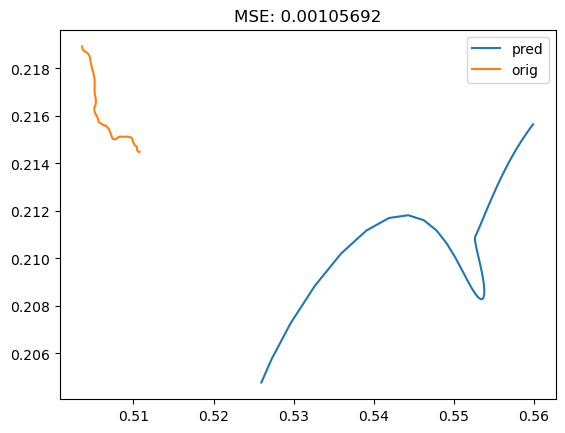

In [20]:
plot_compare(7, sorted_predicted_lines, sequence_train_s, sorted_mse_values, sorted_indices)